## Contact Map Prediction using Prot-LAMBDA model

In this notebook, we demonstrate how to predict contact maps using Prot-LAMBDA model

In [2]:
%cd ..

/net/kihara/scratch/nibtehaz/Prot-LAMBDA


In [3]:
## Load model

import torch

from ProtLAMBDA import ProtLAMBDA

mdl = ProtLAMBDA()

mdl.load_state_dict(torch.load('params/ProtLAMBDA.pth',map_location='cpu'))

/tmp/ipykernel_1755982/713470032.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mdl.load_state_dict(torch.load('params/ProtLAMBDA.pth',map_location='cpu'))


<All keys matched successfully>

In [ ]:
## Load seqs 

from ProtLAMBDA import load_fastas

seqs = load_fastas('sample_protein')

seqs

[['7fjs_L',
  'RTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECQIVLTQSPSSLAVSVGEKVTLSCKSSQSLLYSNNQKNYLAWYQQKSGRSPKLLLHWTSTRESGVPDRFTGSGSGTDFTLTISSVKAEDLAVYYCQQYYTYPWTFGGGTKLEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC'],
 ['7x8v_A',
  'GPGHMMAAEAWRSRFRERVVEAAERWESVGESLATALTHLKSPMHAGDEEEAAAARTRIQLAMGELVDASRNLASAMSLMKVAELLALHGGSVNPSTHLGEISLLGDQYLAERNAGIKLLEAGKDARKAYISVDGCRGNLDAILLLLDHPRVPCVDDFIEEELFVAGDNLQGAIGNAKLGTERAVGARQDVSGAN'],
 ['T1089',
  'MDDNVNDFRPVPYPDEVVGLNPDPDFEPIWEIASPTITVFSSKASNDISYRVPAIAVTKKGSILVFCEARYGTWQDKAGRTDILMKRSTDKGITWTEKNLTNQATSSKLSYMDPTVVVDQVTGKIFLFTSLWDAVGKESAKQGYNNRAIMYTSEDDGLNWTRKDLTDEVEIGIFSGATRMIGSFGPGSGVQMTSSEQYKNRLIVPIRTFKVNEAAGTVSNGGNTAMWSDDNGGTWETGQPNKSGEWMVTEAPDGALIGNIRYNGHRQNYVSTDGGAKWPSFSDYDPIALPTPAKGCAGSVIVKDGWMYYCGAKGIIETTAHDDRGILYLAKAKFFGGHSHTFDPADHMVLYDKAAGYTCMALLPDGDMAIVAELGNEPGFQKLSTRPAEWMRLELFILSTKKPL'],
 ['T1034',
  'LILN

In [29]:
## generate all outputs, keeping only the contact map

with torch.no_grad():
    _, _, _, cm = mdl.get_all(seqs)

In [30]:
## binarize contact map

cm = torch.sigmoid(cm[:,0,:,:])
cm = (cm>0.5).float()

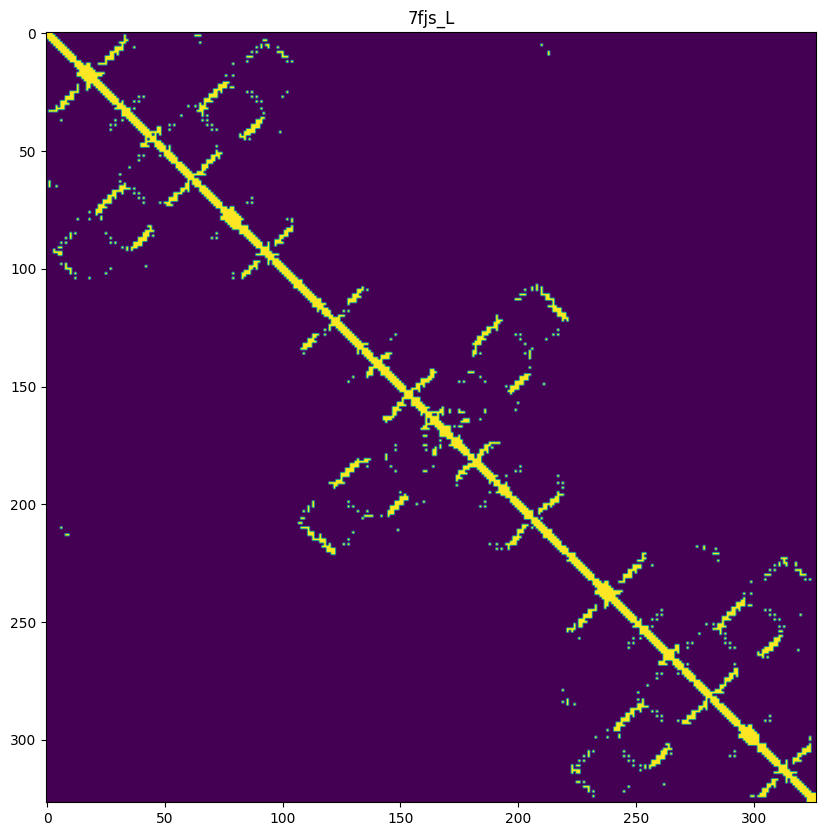

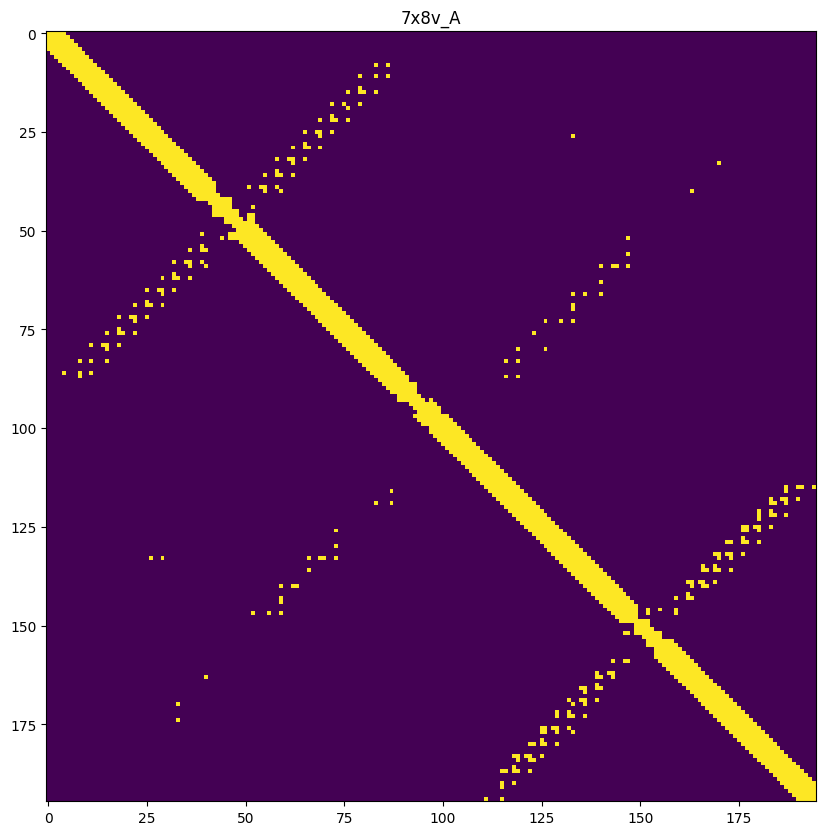

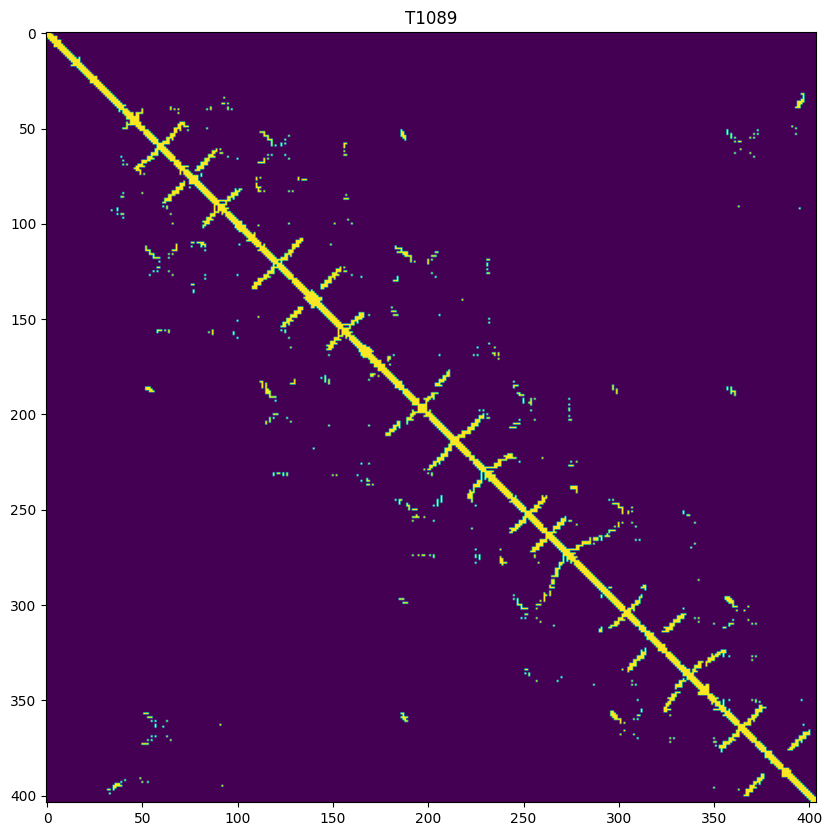

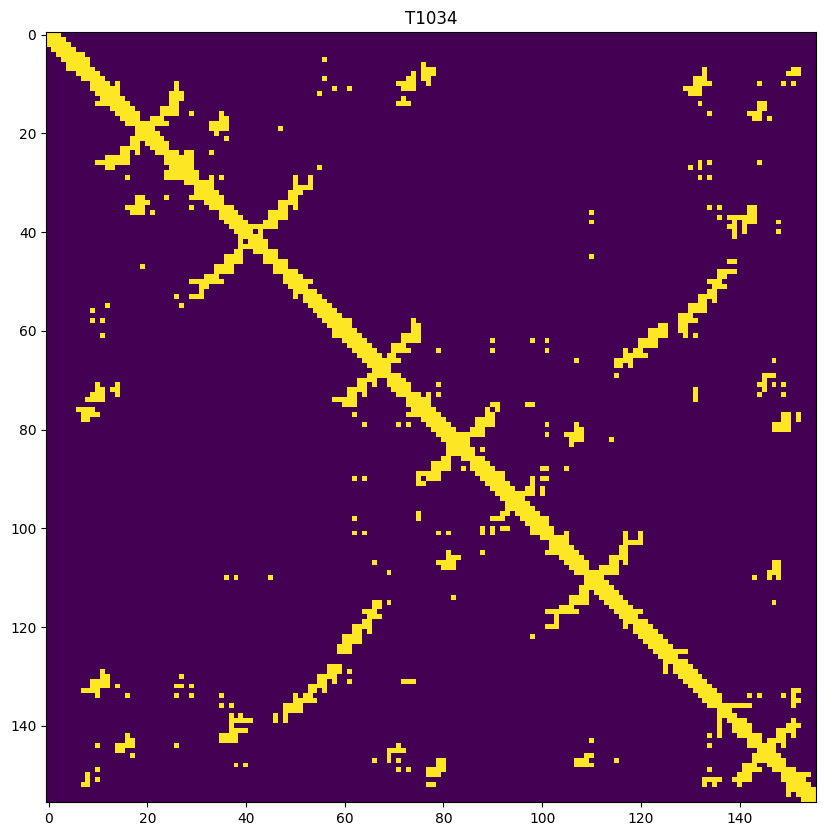

In [31]:
## plot contact maps 

import matplotlib.pyplot as plt

for i in range(len(seqs)):
    plt.figure(figsize=(10,10))
    plt.title(seqs[i][0])
    plt.imshow(cm[i,:len(seqs[i][1]),:len(seqs[i][1])].numpy())
